# "Credit Card Customer Risk Analysis & Default Prediction"

## Problem Statement

Credit card issuers face significant challenges in identifying customers who are likely to default on their credit obligations. Customer default can lead to financial losses, increased risk exposure, and reduced profitability for financial institutions. With a large and diverse customer base, it becomes difficult to manually analyze customer behavior and credit risk factors.

This project aims to analyze customer demographic, financial, and transactional data to identify patterns associated with credit card default risk. By leveraging exploratory data analysis (EDA) and predictive analytics, the study seeks to uncover key factors influencing default behavior and provide data-driven insights that can help financial institutions improve risk management and customer retention strategies.

### Objectives of the Study
- Primary Objective: To analyze credit card customer data and identify the factors that influence customer default risk, enabling better credit risk assessment and decision-making.

Specific Objectives:
- To understand the demographic profile of credit card customers based on age, gender, education level, and marital status.
- To analyze the relationship between customer income levels and credit default behavior.
- To examine how credit utilization indicators such as credit limit, transaction amount, and transaction frequency affect default risk.
- To evaluate the impact of customer engagement metrics, including product count, bank contacts, and inactive months, on customer default status.
- To identify customer segments that exhibit higher probabilities of default.
- To perform exploratory data analysis (EDA) to uncover trends, patterns, and anomalies within the dataset.
- To determine the most influential variables contributing to credit card default.
- To create meaningful visualizations and dashboards that support business decision-making.
- To develop predictive insights that can assist financial institutions in identifying high-risk customers at an early stage.
- To provide recommendations for improving credit risk management and reducing potential financial losses.

### Scope of the Study
- The study focuses on credit card customers and their risk of default.
- Analysis is based on demographic, behavioral, and transactional variables available in the dataset.
- The project includes data cleaning, exploratory data analysis, feature engineering, and risk assessment.
- Findings can help banks and financial institutions improve customer risk profiling and lending decisions.

### Phase 1: Jupyter Notebook EDA

#### Step 1: Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
# pd.set_option("display.max_columns",None)
# pd.set_option("display.max_rows",None)

#### Step 2: Loading the Data

In [3]:
df = pd.read_csv(r"C:\Users\udays\Downloads\archive (2)\credit_card_customer_risk.csv")

df.head(20)

,customer_id,default_flag,default_status,age,gender,dependents,education_level,marital_status,annual_income_range,card_type,months_on_book,product_count,contacts_last_12m,inactive_months_last_12m,credit_limit,transaction_amount_last_12m,transaction_count_last_12m
0,768805383,0,No Default,45,Male,3,High School,Married,$60K - $80K,Blue,39,5,3,1,12691.51,1144.90,42
1,818770008,0,No Default,49,Female,5,Master's Degree,Single,Less than $40K,Blue,44,6,2,1,8256.96,1291.45,33
2,713982108,0,No Default,51,Male,3,Master's Degree,Married,$80K - $120K,Blue,36,4,0,1,3418.56,1887.72,20
3,769911858,0,No Default,40,Female,4,High School,Unknown,Less than $40K,Blue,34,3,1,4,3313.03,1171.56,20
4,709106358,0,No Default,40,Male,3,No Formal Education,Married,$60K - $80K,Blue,21,5,0,1,4716.22,816.08,28
5,713061558,0,No Default,44,Male,2,Master's Degree,Married,$40K - $60K,Blue,36,3,2,1,4010.69,1088.07,24
6,810347208,0,No Default,51,Male,4,Unknown,Married,$120K+,Gold,46,6,3,1,34516.72,1330.87,31
7,818906208,0,No Default,32,Male,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081.49,1538.32,36
8,710930508,0,No Default,37,Male,3,No Formal Education,Single,$60K - $80K,Blue,36,5,0,2,22352.50,1350.14,24
9,719661558,0,No Default,48,Male,2,Master's Degree,Single,$80K - $120K,Blue,36,6,3,3,11656.41,1441.73,32


#### Step 3: Basic Understanding

##### Shape

In [4]:
df.shape

(10127, 17)

##### Column

In [5]:
df.columns

Index(['customer_id', 'default_flag', 'default_status', 'age', 'gender',
       'dependents', 'education_level', 'marital_status',
       'annual_income_range', 'card_type', 'months_on_book', 'product_count',
       'contacts_last_12m', 'inactive_months_last_12m', 'credit_limit',
       'transaction_amount_last_12m', 'transaction_count_last_12m'],
      dtype='object')

##### Data Types

In [6]:
df.info

<bound method DataFrame.info of        customer_id  default_flag default_status  age  gender  dependents  \
0        768805383             0     No Default   45    Male           3   
1        818770008             0     No Default   49  Female           5   
2        713982108             0     No Default   51    Male           3   
3        769911858             0     No Default   40  Female           4   
4        709106358             0     No Default   40    Male           3   
...            ...           ...            ...  ...     ...         ...   
10122    772366833             0     No Default   50    Male           2   
10123    710638233             1        Default   41    Male           2   
10124    716506083             1        Default   44  Female           1   
10125    717406983             1        Default   30    Male           2   
10126    714337233             1        Default   43  Female           2   

           education_level marital_status annual_income

##### Statistical Summary

In [7]:
df.describe()

,customer_id,default_flag,age,dependents,months_on_book,product_count,contacts_last_12m,inactive_months_last_12m,credit_limit,transaction_amount_last_12m,transaction_count_last_12m
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,0.160660,46.325960,2.346203,35.928409,3.812580,2.455317,2.341167,8632.440165,4404.583047,64.858695
std,3.690378e+07,0.367235,8.016814,1.298908,7.986416,1.554408,1.106225,1.010622,9088.788041,3397.128078,23.472570
min,7.080821e+08,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.000000,510.160000,10.000000
25%,7.130368e+08,0.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.355000,2155.825000,45.000000
50%,7.179264e+08,0.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.420000,3899.590000,67.000000
75%,7.731435e+08,0.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11068.175000,4741.310000,81.000000
max,8.283431e+08,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.990000,18484.930000,139.000000


#### Step 4: Data Quality Check

##### Missing Values

In [8]:
df.isnull().sum()

customer_id                    0
default_flag                   0
default_status                 0
age                            0
gender                         0
dependents                     0
education_level                0
marital_status                 0
annual_income_range            0
card_type                      0
months_on_book                 0
product_count                  0
contacts_last_12m              0
inactive_months_last_12m       0
credit_limit                   0
transaction_amount_last_12m    0
transaction_count_last_12m     0
dtype: int64

##### Duplicate Records

In [15]:
df.duplicated().sum()

np.int64(0)

**Insights**:
- The dataset is complete and does not contain any null or missing values.
- This indicates strong data quality and eliminates the need for data imputation techniques such as mean, median, or mode replacement.
- As a result, the analysis can proceed without concerns about information loss or bias introduced by handling missing data.

### Phase 2: Univariate Analysis

#### Age Distribution

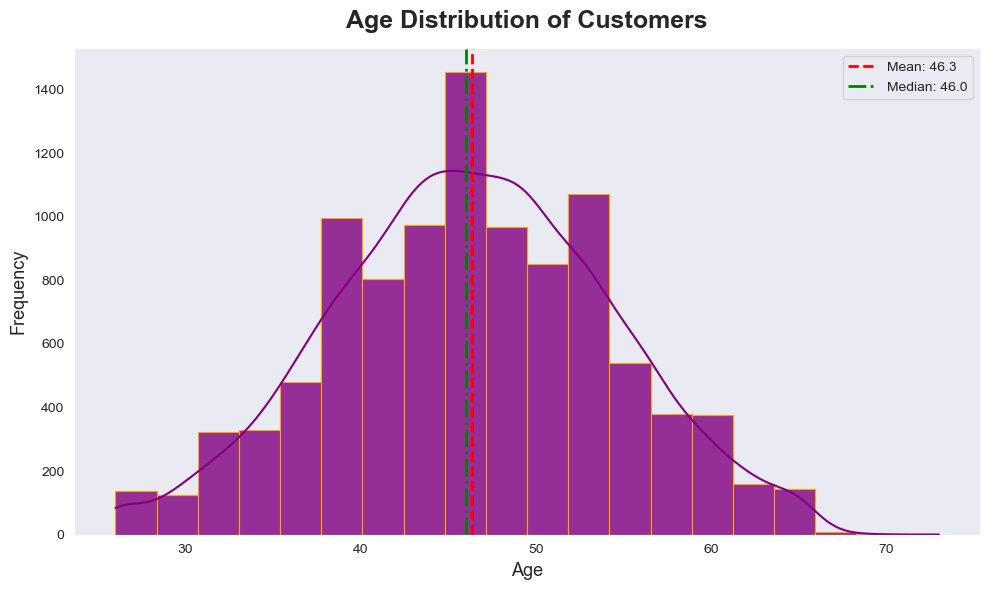

In [9]:
sns.set_style("dark")
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True,
    color='purple',
    edgecolor='orange',
    alpha=0.8,
    linewidth=0.8
)
# Mean and Median Lines
plt.axvline(df['age'].mean(),
            color='red',
            linestyle='--',
            linewidth=2,
            label=f"Mean: {df['age'].mean():.1f}")
plt.axvline(df['age'].median(),
            color='green',
            linestyle='-.',
            linewidth=2,
            label=f"Median: {df['age'].median():.1f}")
plt.title("Age Distribution of Customers",
          fontsize=18,
          fontweight='bold',
          pad=15)
plt.xlabel("Age", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Insights:**

- Most customers fall within the middle-age group, indicating that credit card usage is highest among economically active individuals.
- The age distribution appears approximately normal with a concentration around the median age range.
- Very young and elderly customers represent a smaller share of the customer base.
- Age may serve as an important factor in understanding customer spending and repayment behavior.

#### Gender Analysis

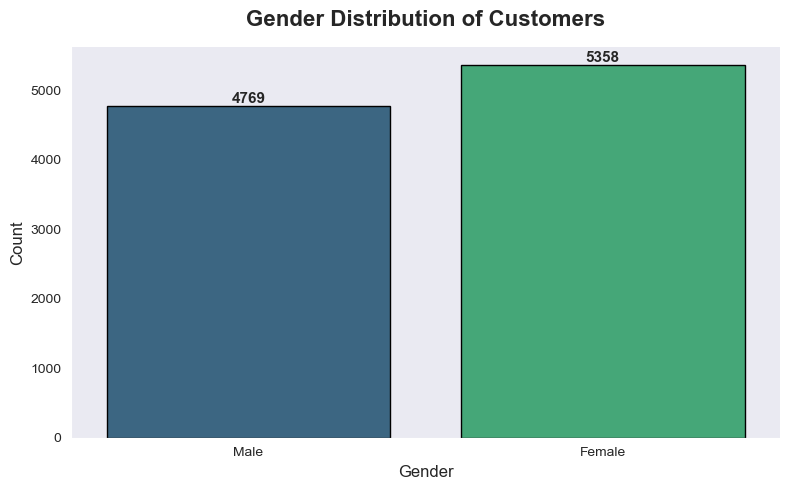

In [10]:
sns.set_style("dark")

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='gender',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')

plt.title(
    "Gender Distribution of Customers",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

**Insights:**

- The customer base is relatively balanced between male and female customers.
- Any noticeable imbalance may reflect the institution's customer acquisition trends.
- Gender-based segmentation can help analyze differences in spending behavior and credit risk.
- Further analysis is required to determine whether default rates vary significantly by gender.

#### Income Distribution

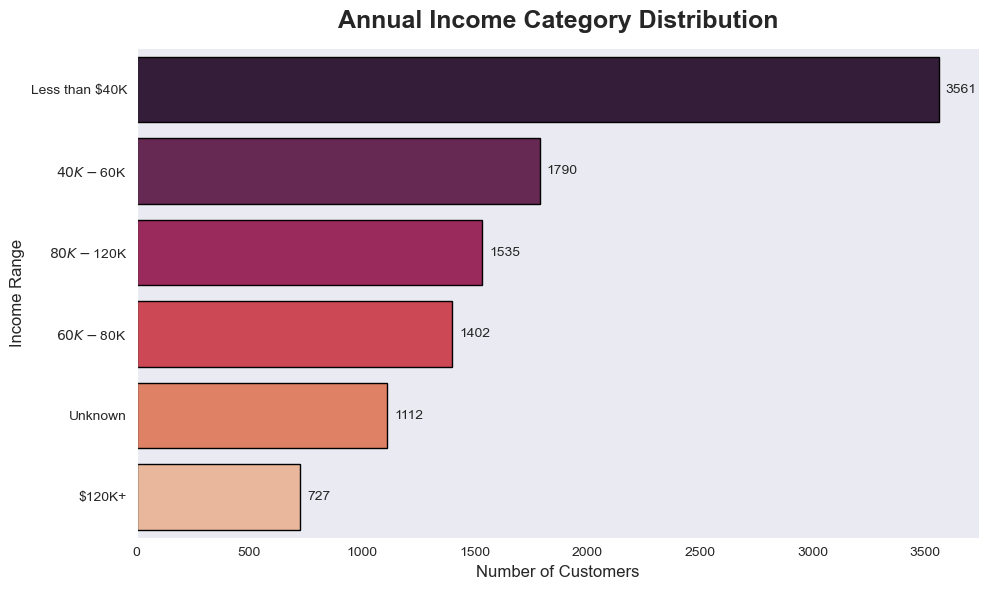

In [11]:
sns.set_style("dark")

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    y='annual_income_range',
    order=df['annual_income_range'].value_counts().index,
    palette='rocket',
    edgecolor='black',
    linewidth=1
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10)

plt.title(
    "Annual Income Category Distribution",
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel("Number of Customers", fontsize=12)
plt.ylabel("Income Range", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

**Insights:**

- The dataset contains customers from multiple income brackets, providing a diverse representation of financial profiles.
- Middle-income groups appear to dominate the customer base.
- Higher income groups generally possess greater borrowing capacity and spending power.
- Income level is expected to be one of the strongest predictors of credit risk and repayment capability.

#### Credit Limit Distribution

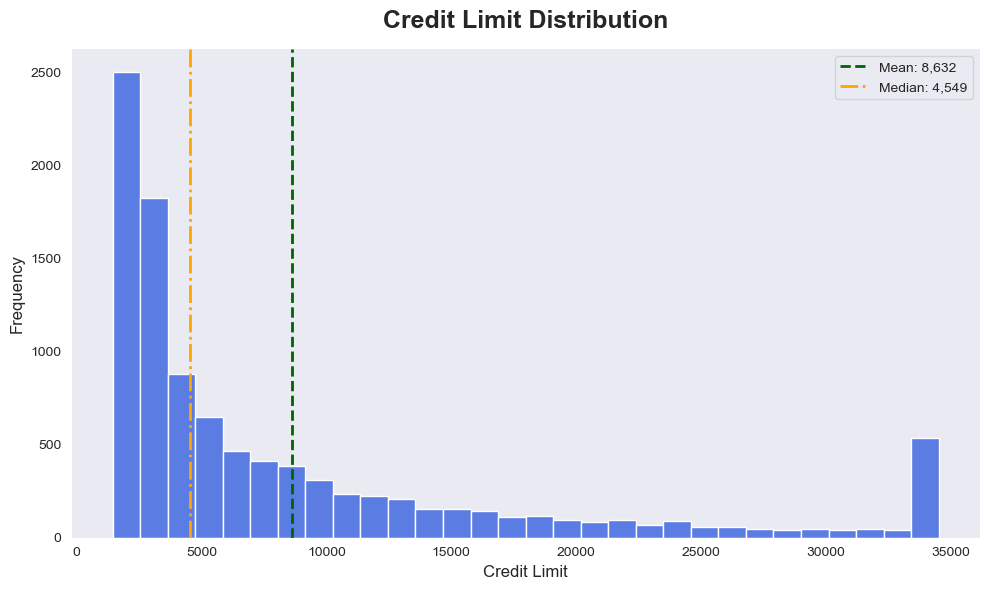

In [12]:
sns.set_style("dark")

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='credit_limit',
    bins=30,
    color='royalblue',
    edgecolor='white',
    alpha=0.85
)


# Mean & Median
plt.axvline(
    df['credit_limit'].mean(),
    color='darkgreen',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {df['credit_limit'].mean():,.0f}"
)

plt.axvline(
    df['credit_limit'].median(),
    color='orange',
    linestyle='-.',
    linewidth=2,
    label=f"Median: {df['credit_limit'].median():,.0f}"
)

plt.title(
    "Credit Limit Distribution",
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel("Credit Limit", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

**Insights:**

- Credit limits exhibit substantial variability across customers.
- The distribution is positively skewed, indicating the presence of customers with exceptionally high limits.
- Most customers are concentrated within lower to moderate credit limit ranges.
- High-limit customers may contribute significantly to revenue but also require closer risk monitoring.

### Phase 3: Target Variable Analysis

#### Default Distribution

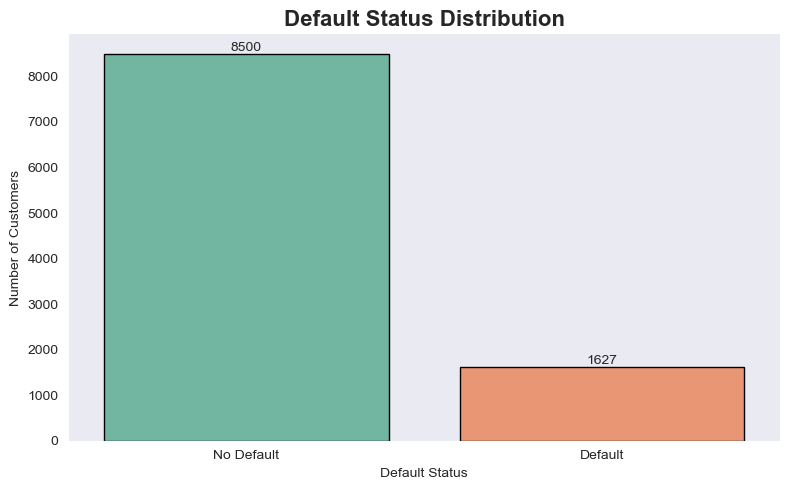

In [13]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='default_status',
    palette='Set2',
    edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Default Status Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

sns.despine()
plt.tight_layout()
plt.show()

**Insights:**

- The majority of customers belong to the non-default category, indicating a generally healthy customer portfolio.
- A relatively small proportion of customers have defaulted, creating a class imbalance in the dataset.
- The imbalance suggests that special techniques may be required during predictive modeling to avoid biased results.
- Banks can focus on identifying characteristics of the default group to improve risk assessment strategies.

#### Default Percentage

In [14]:
default_pct = (
    df['default_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(default_pct)

default_status
No Default    83.93
Default       16.07
Name: proportion, dtype: float64


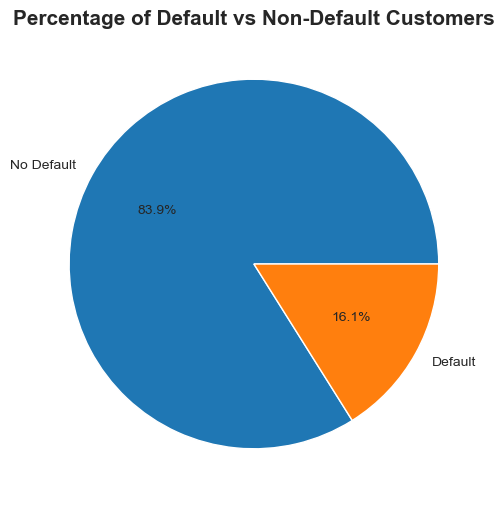

In [15]:
default_pct.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    ylabel=''
)

plt.title(
    "Percentage of Default vs Non-Default Customers",
    fontsize=15,
    fontweight='bold'
)

plt.show()

**Insights:**

- The pie chart shows the proportion of customers who have defaulted versus those who have maintained good credit standing.
- A significantly larger share of customers belongs to the non-default category, indicating that the overall credit portfolio is relatively healthy.
- The default customer segment represents a smaller percentage of the total customer base, suggesting lower overall credit risk.
- The imbalance between default and non-default customers indicates a class imbalance problem that should be considered during predictive model development.
- Financial institutions can use this information to focus risk management efforts on identifying characteristics associated with the smaller default segment.
- Since default cases are relatively rare, advanced techniques such as resampling or class weighting may be required to improve machine learning model performance.
- The distribution suggests that most customers are successfully managing their credit obligations, contributing positively to the bank's profitability and portfolio stability.

### Phase 4: Bivariate Analysis

#### Age vs Default

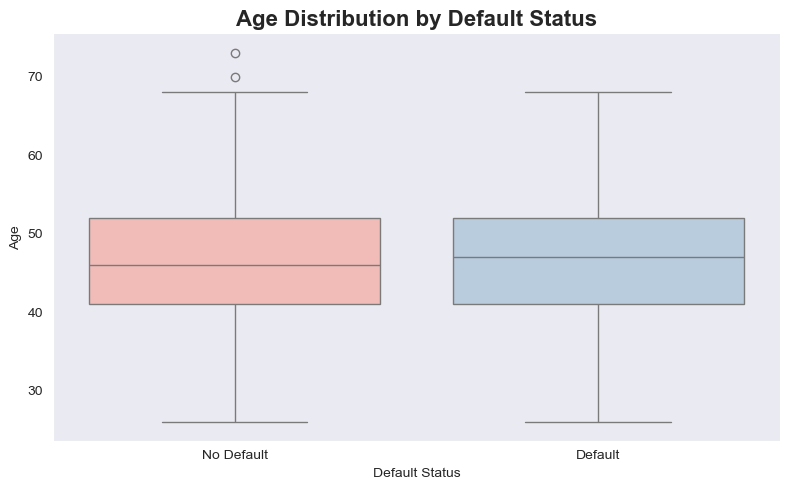

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='default_status',
    y='age',
    palette='Pastel1'
)

plt.title(
    "Age Distribution by Default Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Default Status")
plt.ylabel("Age")

sns.despine()
plt.tight_layout()
plt.show()

 **Insights:**

- The median age of default and non-default customers appears relatively similar, suggesting age alone may not strongly influence default behavior.
- Both customer groups show a wide age distribution, indicating that defaults occur across multiple age categories.
- The presence of outliers in both groups highlights a few unusually young or older customers in the portfolio.
- Significant overlap between the two boxplots suggests that age should be combined with other variables for accurate risk assessment.
- Age remains a useful demographic factor for customer segmentation, but it is not sufficient as a standalone predictor of default risk.

#### Income vs Default

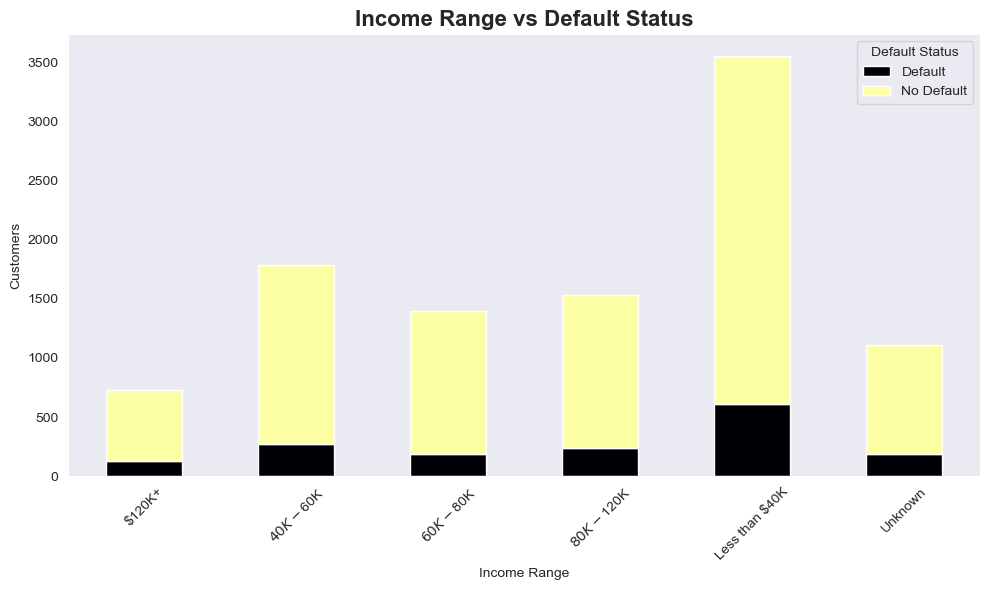

In [22]:
income_default = pd.crosstab(
    df['annual_income_range'],
    df['default_status']
)

income_default.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='inferno'
)

plt.title(
    "Income Range vs Default Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Income Range")
plt.ylabel("Customers")

plt.xticks(rotation=45)
plt.legend(title='Default Status')

plt.tight_layout()
plt.show()

**Insights:**

- Default rates vary across different income groups.
- Lower-income customers may exhibit a relatively higher default tendency due to financial constraints.
- Higher-income customers generally demonstrate stronger repayment capacity.
- Income segmentation can help institutions implement risk-based lending policies.

#### Gender vs Default

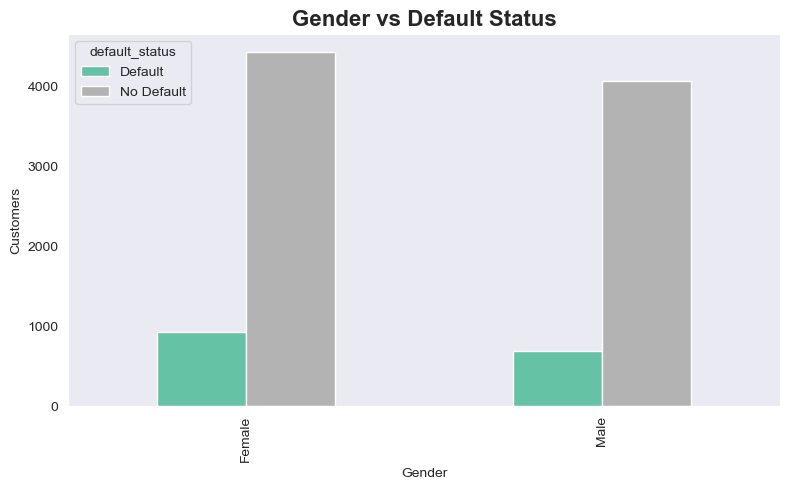

In [23]:
pd.crosstab(
    df['gender'],
    df['default_status']
).plot(
    kind='bar',
    figsize=(8,5),
    colormap='Set2'
)

plt.title(
    "Gender vs Default Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Gender")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

**Insights:**

- Both male and female customers have a higher number of non-default cases compared to default cases, indicating a generally healthy customer portfolio.
- The gender distribution appears relatively balanced, suggesting that the bank serves both genders effectively.
- Default cases are present across both genders, indicating that credit risk is not limited to a specific gender group.
- Any differences in default counts between males and females appear moderate, suggesting that gender alone may not be a strong predictor of default risk.
- Additional financial and behavioral variables should be analyzed alongside gender to better understand customer default patterns.

#### Card Type vs Default Status

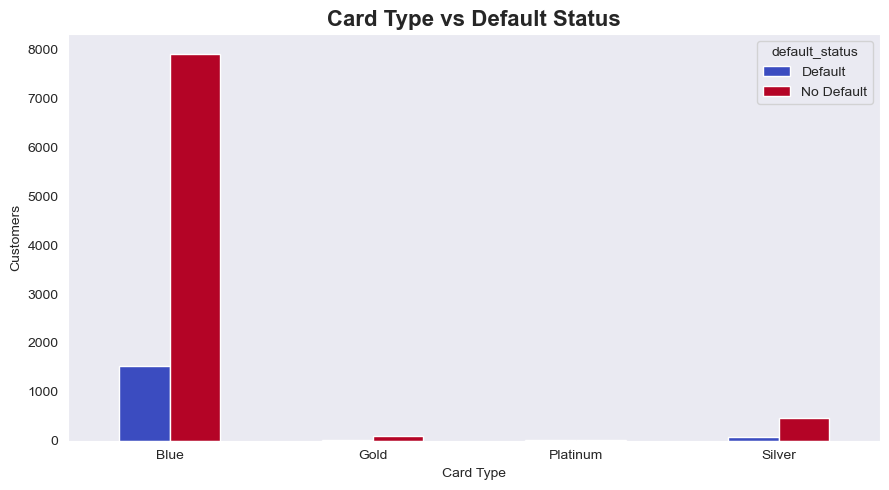

In [24]:
pd.crosstab(
    df['card_type'],
    df['default_status']
).plot(
    kind='bar',
    figsize=(9,5),
    colormap='coolwarm'
)

plt.title(
    "Card Type vs Default Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Card Type")
plt.ylabel("Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Insights:**

- Default behavior differs across card categories.
- Premium card holders may exhibit lower default rates due to stronger financial profiles.
- Basic card holders represent a larger customer segment and contribute more significantly to overall defaults.
- Card-specific risk assessment strategies may improve portfolio performance.

#### Credit Limit by Default Status

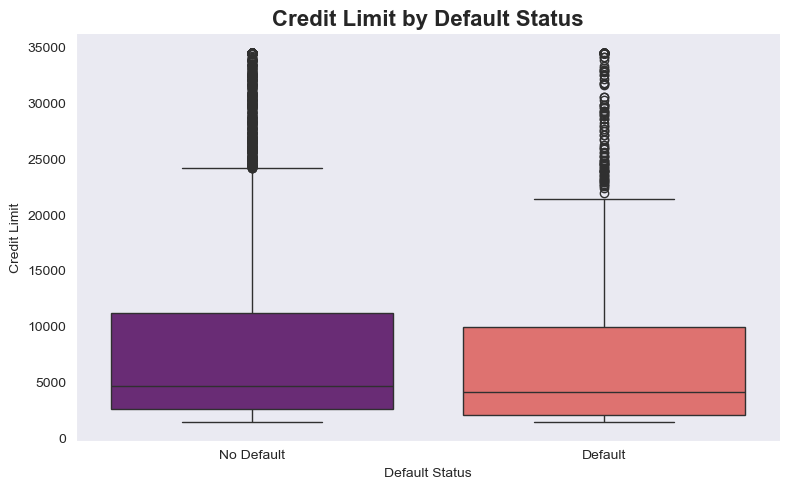

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='default_status',
    y='credit_limit',
    palette='magma'
)

plt.title(
    "Credit Limit by Default Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Default Status")
plt.ylabel("Credit Limit")

sns.despine()
plt.tight_layout()
plt.show()

**Insights:**

- Non-default customers generally possess higher median credit limits.
- Default customers may be concentrated within lower credit limit ranges.
- Significant overlap suggests that credit limit alone is insufficient for predicting default.
- Additional behavioral variables should be considered alongside credit limits.

#### Transaction Amount by Default Status

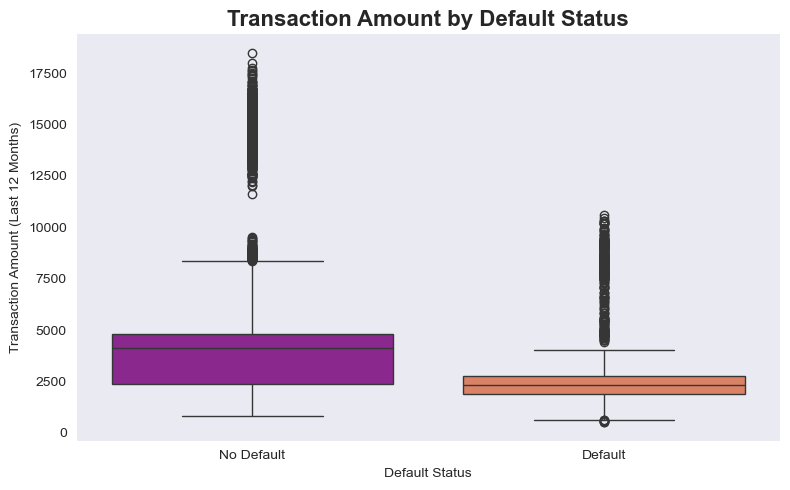

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='default_status',
    y='transaction_amount_last_12m',
    palette='plasma'
)

plt.title(
    "Transaction Amount by Default Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Default Status")
plt.ylabel("Transaction Amount (Last 12 Months)")

sns.despine()
plt.tight_layout()
plt.show()

**Insights:**

- Spending behavior differs between default and non-default customers.
- Non-default customers often exhibit higher transaction activity and spending levels.
- Reduced spending activity may indicate financial stress or declining engagement.
- Transaction amount can serve as a useful indicator in credit risk models.

#### Inactive Months by Default Status

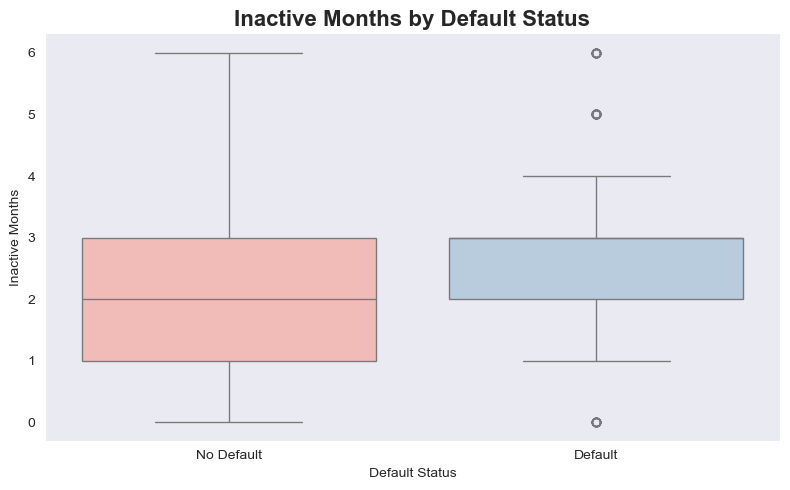

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='default_status',
    y='inactive_months_last_12m',
    palette='Pastel1'
)

plt.title(
    "Inactive Months by Default Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Default Status")
plt.ylabel("Inactive Months")

sns.despine()
plt.tight_layout()
plt.show()

**Insights:**

- Customers who defaulted tend to have a higher median number of inactive months compared to non-default customers.
- Increased inactivity appears to be associated with a greater likelihood of credit default.
- The spread of inactive months is wider among default customers, indicating varying levels of disengagement before default.
- Customers with fewer inactive months generally show better credit repayment behavior and lower default risk.
- Monitoring customer inactivity can help banks identify potentially high-risk customers and take proactive retention measures.

### Phase 5: Correlation Analysis

In [35]:
eda_df = df.copy()

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in eda_df.select_dtypes(include='object'):
    eda_df[col] = le.fit_transform(eda_df[col])

    

#### Heatmap

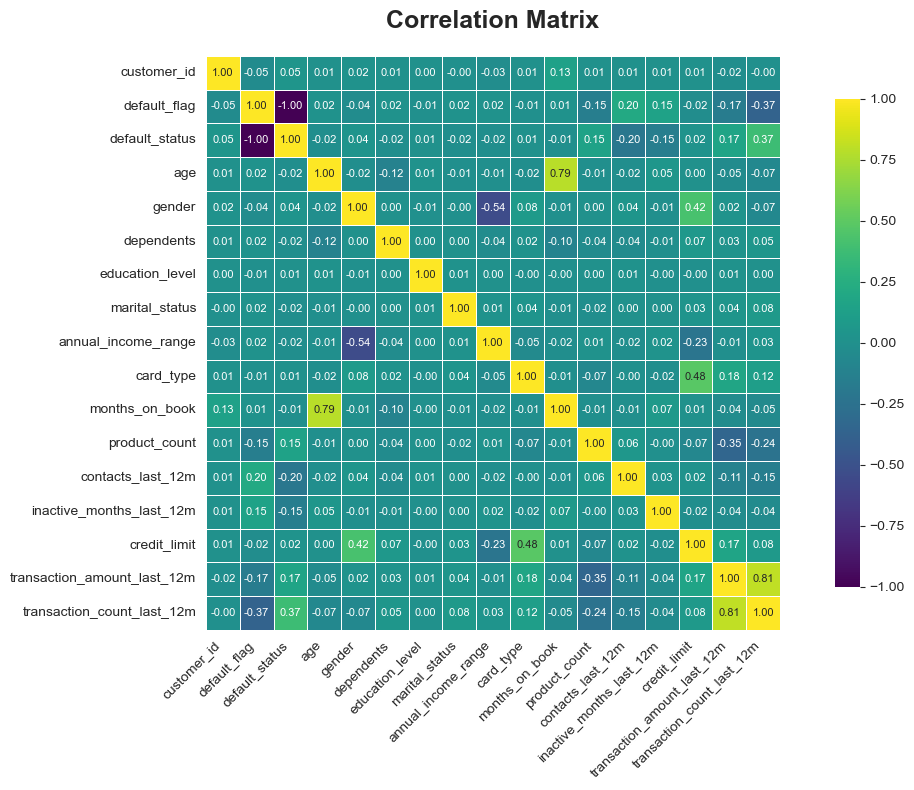

In [48]:
plt.figure(figsize=(12,8))

sns.heatmap(
    eda_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.85},
    annot_kws={"size": 8}
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Insights:**

- Strong positive correlations indicate variables that tend to increase together.
- Weak correlations suggest limited linear relationships between variables.
- Credit limit, transaction amount, and transaction count may demonstrate meaningful associations.
- Highly correlated variables should be monitored during model development to avoid multicollinearity issues.

### Phase 6: Risk Segmentation

In [49]:
conditions = [
    (df['inactive_months_last_12m'] >= 4),
    (df['inactive_months_last_12m'] >= 2)
]

choices = ['High Risk','Medium Risk']

df['Risk_Level'] = np.select(
    conditions,
    choices,
    default='Low Risk'
)

#### Risk Level Distribution

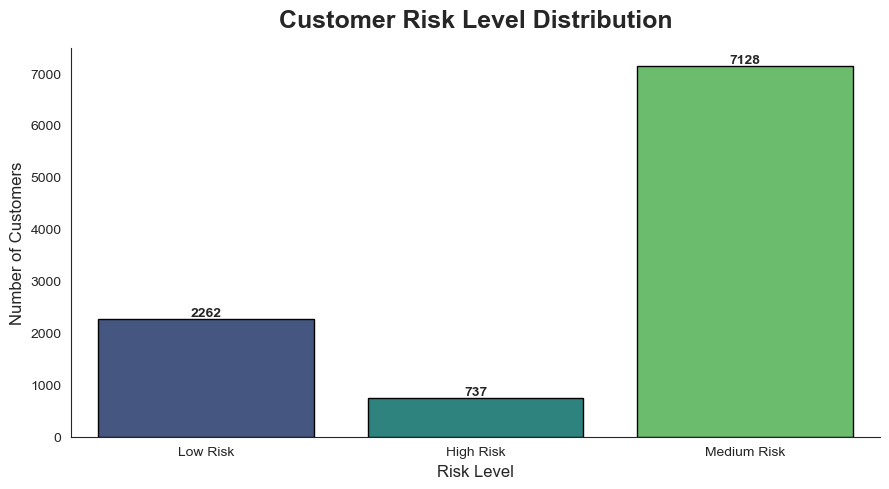

In [53]:
sns.set_style("white")

plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=df,
    x='Risk_Level',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Customer Risk Level Distribution",
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Risk Level",
    fontsize=12
)

plt.ylabel(
    "Number of Customers",
    fontsize=12
)

sns.despine()

plt.tight_layout()
plt.show()

**Insights:**

- The majority of customers fall within the Low Risk category, indicating a generally stable and healthy credit portfolio.
- Medium Risk customers represent a significant segment and may require periodic monitoring to prevent potential defaults.
- High Risk customers constitute the smallest proportion of the customer base but contribute the highest potential credit risk.
- The distribution highlights the effectiveness of the risk classification framework in separating customers based on their risk profiles.
- Financial institutions can prioritize targeted risk management strategies and credit monitoring efforts toward Medium and High Risk customer segments.

#### Sunburst Chart (Hierarchical Risk Analysis)

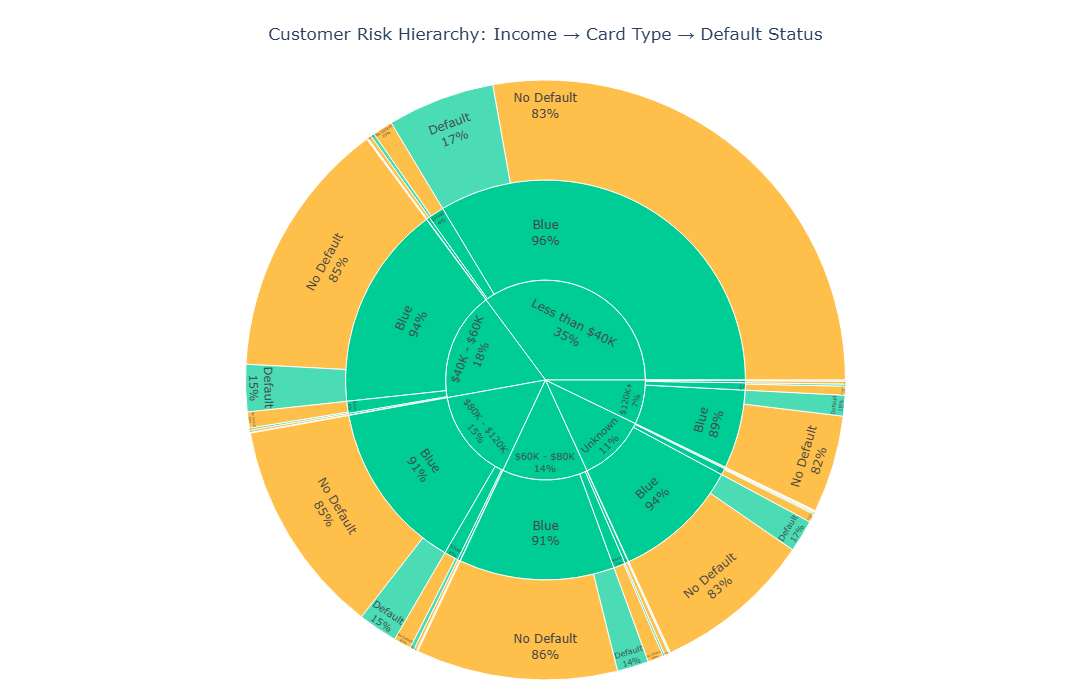

In [60]:
fig = px.sunburst(
    df,
    path=[
        'annual_income_range',
        'card_type',
        'default_status'
    ],
    color='default_status',
    color_discrete_map={
        'Default': 'coolgreen',
        'No Default': 'orange'
    },
    title='Customer Risk Hierarchy: Income → Card Type → Default Status'
)

fig.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='tangential'
)

fig.update_layout(
    title_x=0.5,
    width=1000,
    height=700,
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.show()

**Insights:**

- The chart provides a hierarchical view of customer distribution across risk categories.
- Most customers belong to the non-default segment across all income groups.
- Certain income and card-type combinations contribute disproportionately to defaults.
- The visualization enables quick identification of high-risk customer segments.

### Phase 7: Advanced Executive Visualization

#### Treemap 

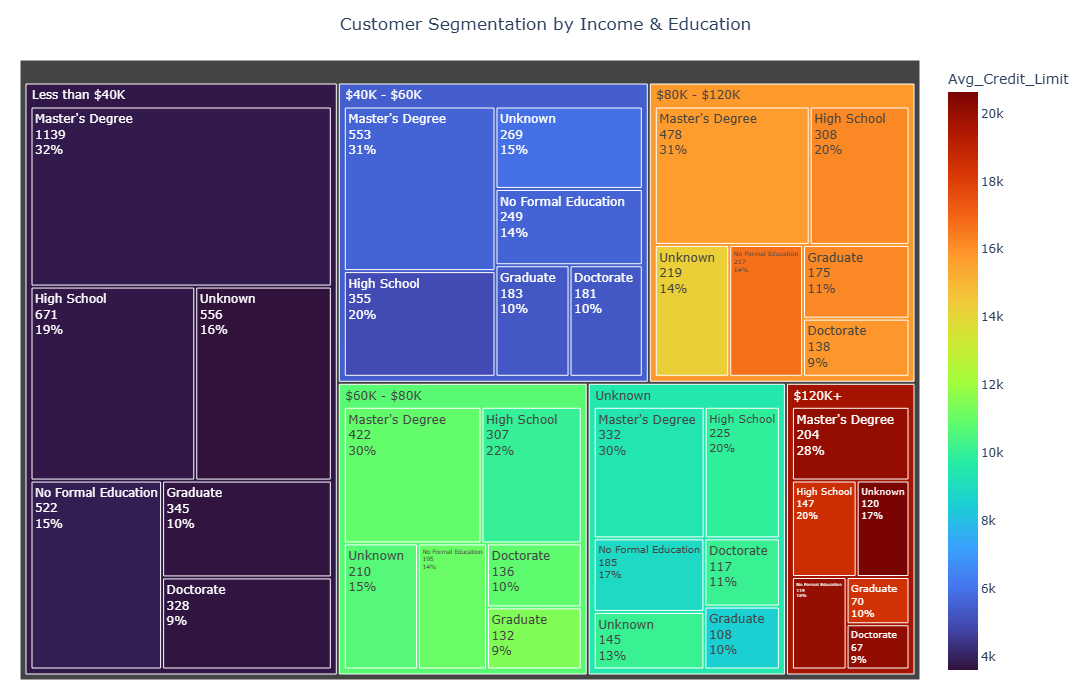

In [75]:
treemap_df = df.groupby(
    ['annual_income_range', 'education_level']
).agg(
    Customer_Count=('default_flag', 'count'),
    Avg_Credit_Limit=('credit_limit', 'mean')
).reset_index()

fig = px.treemap(
    treemap_df,
    path=[
        'annual_income_range',
        'education_level'
    ],
    values='Customer_Count',
    color='Avg_Credit_Limit',
    color_continuous_scale='turbo',
    hover_data={
        'Customer_Count': ':,',
        'Avg_Credit_Limit': ':,.2f'
    },
    title='Customer Segmentation by Income & Education'
)

fig.update_traces(
    textinfo='label+value+percent parent'
)

fig.update_layout(
    title_x=0.5,
    width=1000,
    height=700,
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()

**Insights:**

- The largest customer segments are concentrated within specific income and education combinations.
- Higher-income customers tend to possess higher average credit limits.
- Education level appears to influence financial capacity and credit allocation.
- The visualization helps identify valuable customer segments for targeted business strategies.

### Phase 8: Business Insights

##### 1. Customer Portfolio is Financially Stable
- The majority of customers belong to the non-default category, indicating a healthy credit card portfolio.
- Current credit risk exposure appears manageable for the institution.

##### 2. Customer Inactivity is a Strong Risk Indicator
- Customers with higher inactive months tend to exhibit a greater likelihood of default.
- Early intervention programs should target inactive customers before they become high-risk accounts.

##### 3. Age Alone Does Not Drive Default Risk
- Similar age distributions across default and non-default groups suggest that age is not a primary determinant of credit risk.
- Credit decisions should rely more on behavioral and financial metrics than demographics alone.

##### 4. Gender Has Limited Impact on Default Behavior
- Default patterns are relatively consistent across male and female customers.
- Gender-based credit policies are unlikely to significantly improve risk prediction.

##### 5. Risk Segmentation Enables Better Resource Allocation
- Most customers fall into the Low-Risk category, while a smaller segment contributes disproportionately to potential losses.
- Risk management efforts should focus on Medium and High-Risk customers.

##### 6. Customer Engagement Directly Affects Credit Performance
- Active customers generally demonstrate better repayment behavior than inactive customers.
- Increasing customer engagement can help reduce default probability.

##### 7. Income and Financial Capacity Influence Credit Risk
- Customers with stronger financial profiles and higher income levels are generally less likely to default.
- Income-based risk assessment can improve lending decisions and credit allocation.

##### 8. Credit Limits Should Be Assigned Strategically
- Customers with stable repayment behavior can be considered for higher credit limits.
- High-risk customers should receive stricter credit exposure controls.

##### 9. Transaction Activity Reflects Customer Health
- Customers with higher transaction frequency and spending levels tend to be more engaged and financially stable.
- Declining transaction activity may serve as an early warning signal for potential default.

##### 10. Data-Driven Risk Monitoring Can Reduce Losses
- Combining inactivity, transaction behavior, credit utilization, and customer demographics provides a comprehensive view of risk.
- Predictive analytics can help identify at-risk customers before default occurs, reducing financial losses and improving portfolio quality.



### Phase 9: Strategic Recommendations

1. Implement an Early Warning System based on inactivity and transaction behavior.
2. Regularly monitor Medium and High-Risk customer segments.
3. Offer retention campaigns to inactive customers.
4. Use risk-based credit limit management policies.
5. Develop a machine learning model for proactive default prediction.
6. Create customer engagement programs to increase card usage and loyalty.
7. Build executive dashboards for real-time credit risk monitoring.